In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Num_iter=int(input("Please Enter the iteration Number="))

Please Enter the iteration Number= 500


In [31]:
# Load the dataset from CSV
df = pd.read_csv('C:/Users/IITIEE/Desktop/SOUMEN DAS/Data_set/USA_Housing.csv')
print(df.head())

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...  
2  9127 Eli

In [32]:
# Summary statistics of the dataset
print(df.describe())

       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
count       5000.000000          5000.000000                5000.000000   
mean       68583.108984             5.977222                   6.987792   
std        10657.991214             0.991456                   1.005833   
min        17796.631190             2.644304                   3.236194   
25%        61480.562388             5.322283                   6.299250   
50%        68804.286404             5.970429                   7.002902   
75%        75783.338666             6.650808                   7.665871   
max       107701.748378             9.519088                  10.759588   

       Avg. Area Number of Bedrooms  Area Population         Price  
count                   5000.000000      5000.000000  5.000000e+03  
mean                       3.981330     36163.516039  1.232073e+06  
std                        1.234137      9925.650114  3.531176e+05  
min                        2.000000       172.61

In [33]:
# Check for missing values
print(df.isnull().sum())

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


In [34]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

C:\Users\IITIEE\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\IITIEE\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\IITIEE\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\IITIEE\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is

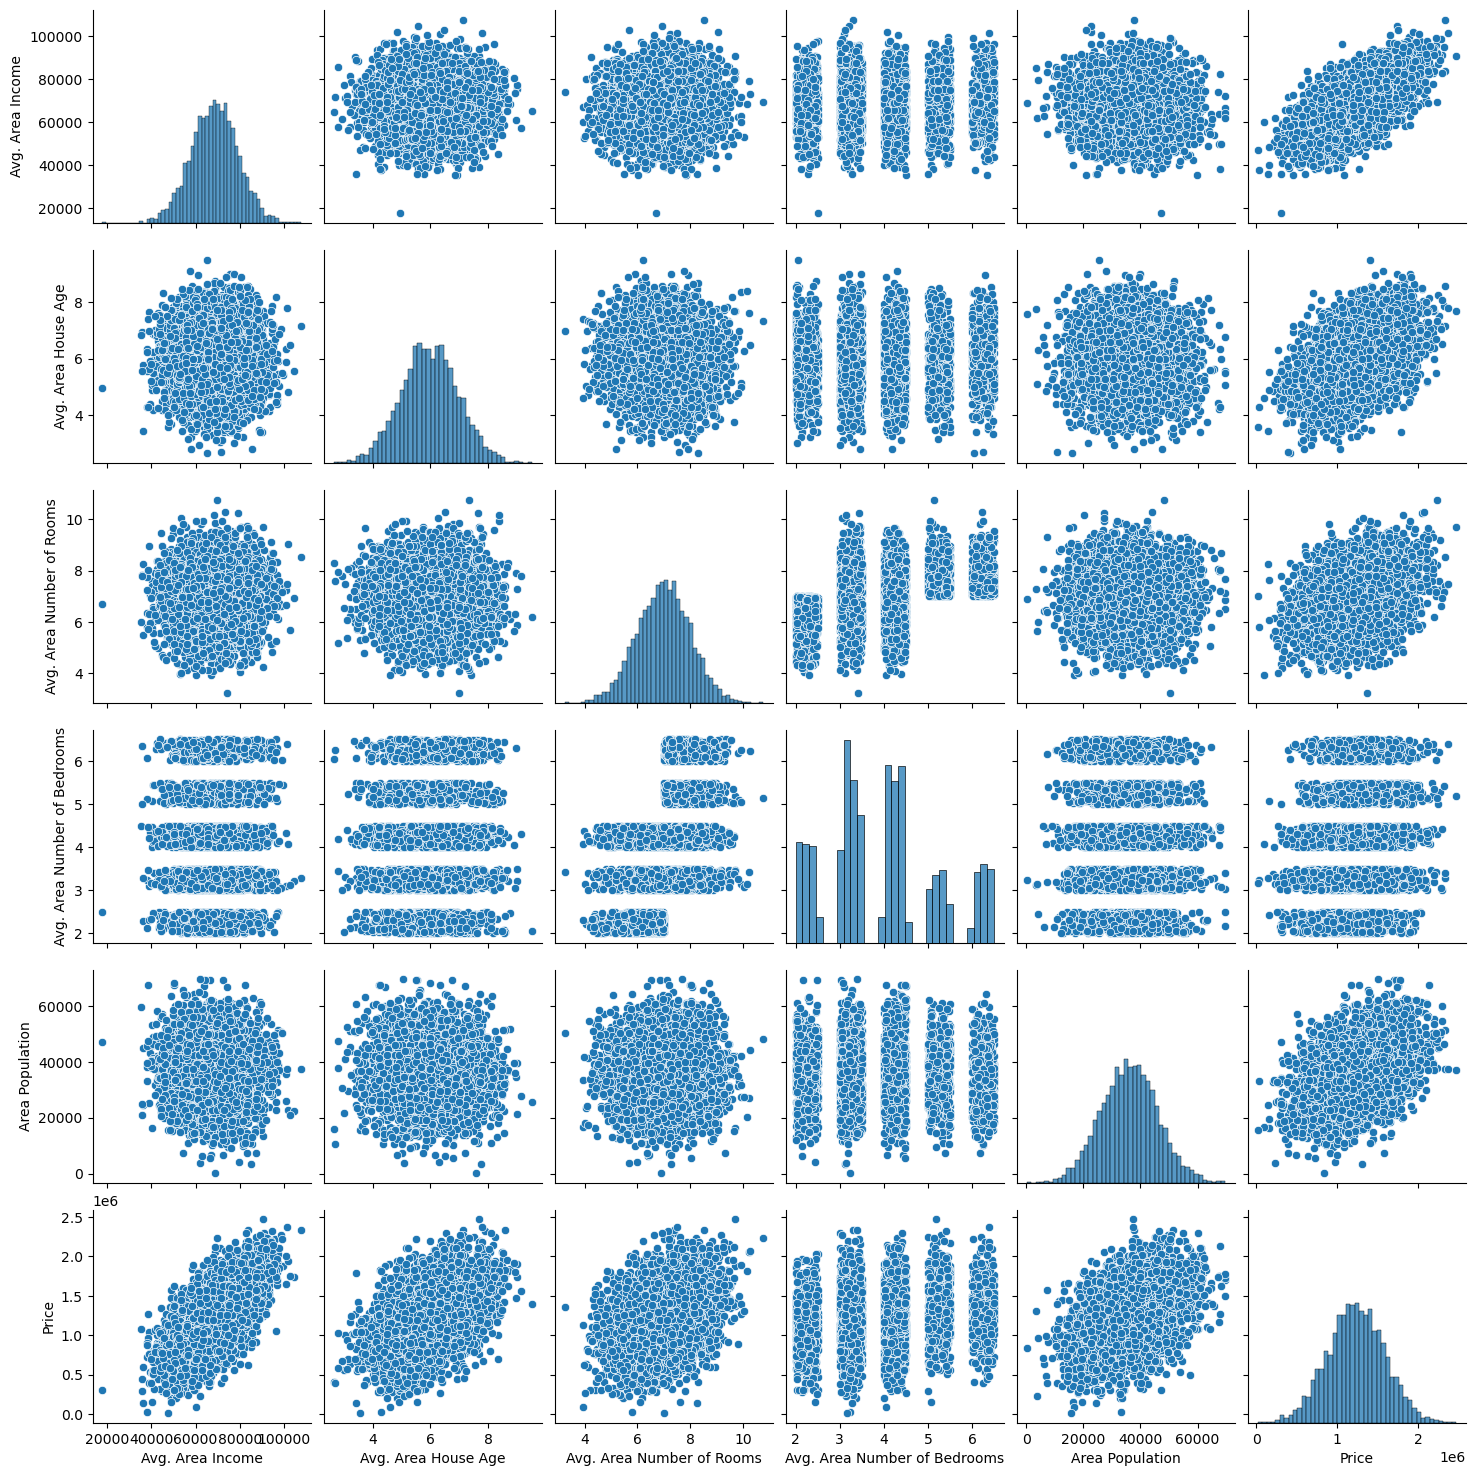

In [35]:
df.drop(['Address'], axis = 1 ,inplace=True)
sns.pairplot(df, palette="husl")


In [36]:
from sklearn.preprocessing import MinMaxScaler
print(df)
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df.to_numpy())
df_scaled = pd.DataFrame(df_scaled, columns=[
  'Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms','Area Population','Price'])
 
print("Scaled Dataset Using MinMaxScaler")
df_scaled.head()

features = MinMaxScaler().fit_transform(df_scaled)
print(features)

      Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0         79545.458574             5.682861                   7.009188   
1         79248.642455             6.002900                   6.730821   
2         61287.067179             5.865890                   8.512727   
3         63345.240046             7.188236                   5.586729   
4         59982.197226             5.040555                   7.839388   
...                ...                  ...                        ...   
4995      60567.944140             7.830362                   6.137356   
4996      78491.275435             6.999135                   6.576763   
4997      63390.686886             7.250591                   4.805081   
4998      68001.331235             5.534388                   7.130144   
4999      65510.581804             5.992305                   6.792336   

      Avg. Area Number of Bedrooms  Area Population         Price  
0                             4.09     2308

In [37]:
mean=df_scaled["Price"].mean()
print("mean of price \n",mean)

mean of price 
 0.4957484988842136


In [38]:
cutoff =mean                            # Decide on a cutoff limit
print(cutoff)
df_scaled['Buys House(class Label)'] = [0 if x > cutoff else 1 for x in df_scaled['Price']]
print(df_scaled)


0.4957484988842136
      Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0             0.686822             0.441986                   0.501502   
1             0.683521             0.488538                   0.464501   
2             0.483737             0.468609                   0.701350   
3             0.506630             0.660956                   0.312430   
4             0.469223             0.348556                   0.611851   
...                ...                  ...                        ...   
4995          0.475738             0.754359                   0.385619   
4996          0.675097             0.633450                   0.444024   
4997          0.507135             0.670026                   0.208534   
4998          0.558419             0.420389                   0.517579   
4999          0.530715             0.486997                   0.472678   

      Avg. Area Number of Bedrooms  Area Population     Price  \
0                         0

In [39]:
X = df_scaled[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population','Price']]
print(X)
y = df_scaled['Buys House(class Label)']
print(y)

      Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0             0.686822             0.441986                   0.501502   
1             0.683521             0.488538                   0.464501   
2             0.483737             0.468609                   0.701350   
3             0.506630             0.660956                   0.312430   
4             0.469223             0.348556                   0.611851   
...                ...                  ...                        ...   
4995          0.475738             0.754359                   0.385619   
4996          0.675097             0.633450                   0.444024   
4997          0.507135             0.670026                   0.208534   
4998          0.558419             0.420389                   0.517579   
4999          0.530715             0.486997                   0.472678   

      Avg. Area Number of Bedrooms  Area Population     Price  
0                         0.464444         0.32

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from qiskit_algorithms.utils import algorithm_globals

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=101)
# Building the Linear Regression Model
model = LinearRegression()
print("Training data =\n",X_train)
print("type =\n",type(X_train))
print("Training label=\n",y_train)
# Fitting the model on the training data
model.fit(X_train, y_train)


Training data =
       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
3413          0.570069             0.578259                   0.383819   
1610          0.556923             0.399965                   0.813839   
3459          0.432007             0.415048                   0.516479   
4293          0.684207             0.233190                   0.569159   
1039          0.612030             0.558056                   0.515786   
...                ...                  ...                        ...   
4171          0.431722             0.320378                   0.574467   
599           0.587288             0.567868                   0.439136   
1361          0.420724             0.158789                   0.482774   
1547          0.503284             0.478700                   0.355858   
4959          0.637140             0.727365                   0.691780   

      Avg. Area Number of Bedrooms  Area Population     Price  
3413                      0.51

LinearRegression()

In [41]:
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix

print("X_test data =\n",X_test)
y_pred = model.predict(X_test)
#print("Y_Test data\n",y_test,"\n")
print("y_predict data =\n",y_pred,"\n")

X_test data =
       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
1718          0.544778             0.446972                   0.605979   
2511          0.493719             0.331858                   0.557128   
345           0.621171             0.599662                   0.678004   
2521          0.490655             0.521331                   0.446201   
54            0.613381             0.311562                   0.542799   
...                ...                  ...                        ...   
3900          0.665359             0.517296                   0.488228   
3753          0.546449             0.364920                   0.685955   
3582          0.600426             0.476666                   0.554916   
2392          0.772764             0.346420                   0.524839   
3343          0.583665             0.467218                   0.471319   

      Avg. Area Number of Bedrooms  Area Population     Price  
1718                      0.5155

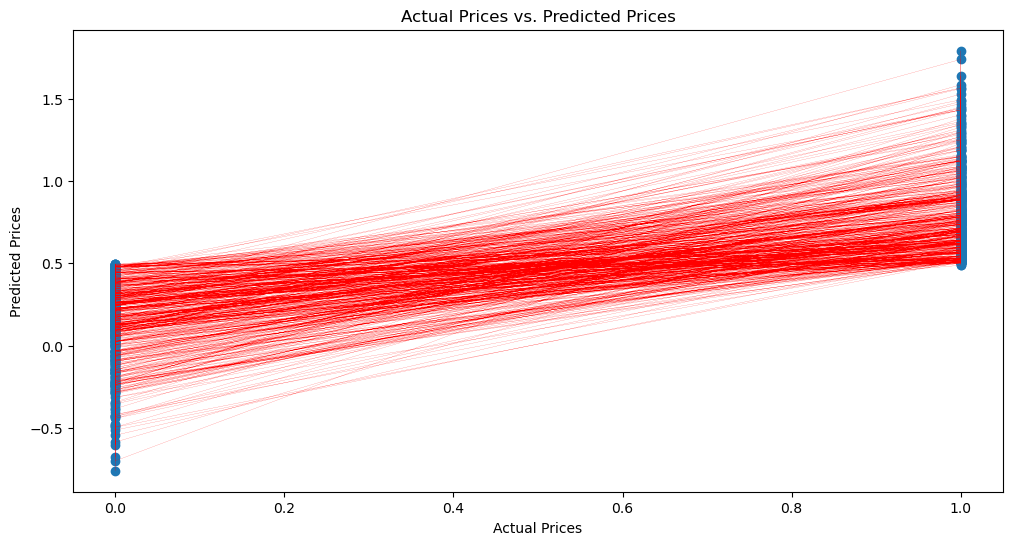

In [42]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs. Predicted Prices")
plt.plot(y_test,y_pred, color='red',linewidth=0.1)
plt.show()

In [43]:
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
print("Y_Test data\n",y_test,"\n")
print("predicted data\n",y_pred,"\n")



Y_Test data
 1718    0
2511    1
345     0
2521    1
54      1
       ..
3900    0
3753    1
3582    0
2392    1
3343    1
Name: Buys House(class Label), Length: 1000, dtype: int64 

predicted data
 [ 0.47911756  0.91847998 -0.03098858  0.68884782  0.83378981  1.06702926
  0.59124716  1.08910457  0.18772818  0.42395656  0.24736888  0.44202488
 -0.10712196  0.19146412  0.26460148  0.63216094  1.0749852   0.60380764
  0.66866235  0.32265825  1.44210815  0.24528868 -0.11291043  0.52548438
  0.63355623 -0.18688355 -0.14436733  0.2758353   0.34122138  0.21303829
  1.18768828 -0.16876821  0.10833284  0.71468193  0.24876175  0.76994051
  0.56250722  0.88849366  0.37593523  1.0466065   0.29048879  1.06154384
  1.08412485 -0.18904005 -0.03591466  0.85434508  0.4830997   0.90083669
  0.71215719  0.17582754  0.15132282  0.50284076  0.44530384  0.53176896
  1.01626985  0.60424612  0.58326866  0.62245502  0.31885504  1.06542603
  0.2003723   0.69704632  1.0282539   0.4777568   0.26868993  0.3468698

In [44]:

y_pred_classes = np.zeros_like(y_pred)    # initialise a matrix full with zeros
y_pred_classes[y_pred > cutoff] = 1       # add a 1 if the cutoff was breached
print("\n class label for y_pred_classes=\n",y_pred_classes)

cnf=confusion_matrix(y_test, y_pred_classes)
print("confusion matrix =\n",cnf)


TN,FP, FN, TP = cnf.ravel()
print("\n")
print("No of TN =",TN)
print("No of FP =",FP)
print("No of FN =",FN)
print("No of TP =",TP)


 class label for y_pred_classes=
 [0. 1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 1.
 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 1. 0. 1. 1. 0. 0. 1. 0. 1.
 1. 0. 0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0.
 1. 0. 1. 1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 0. 1. 1.
 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 1. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0.
 1. 1. 0. 0. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0. 0.
 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0.
 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0.
 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1.
 0. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0.
 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0.
 0. 1. 1. 1. 0. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1.
 1. 0. 1. 1. 1. 

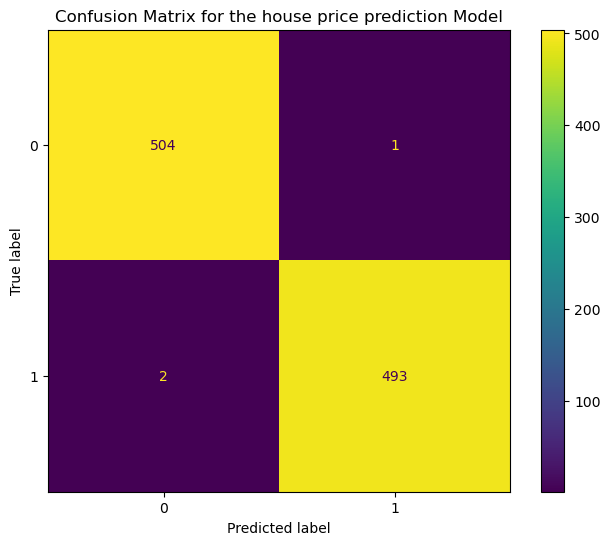

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Change figure size and increase dpi for better resolution
# and get reference to axes object
fig, ax = plt.subplots(figsize=(8,6), dpi=100)

# initialize using the raw 2D confusion matrix 
# and output labels (in our case, it's 0 and 1)
display = ConfusionMatrixDisplay(cnf)

# set the plot title using the axes object
ax.set(title='Confusion Matrix for the house price prediction Model')

# show the plot. 
# Pass the parameter ax to show customizations (ex. title) 
display.plot(ax=ax);


In [46]:
new_data = [[0.686822, 0.599662, 0.701350 ,0.695556, 0.528582,0.507384],[0.784822, 0.394662, 0.851350 ,0.785556, 0.548582,0.577384]]
predicted_price = model.predict(new_data)

print("Predicted Price:", predicted_price[0])
print("Predicted Price:", predicted_price[1])

Predicted Price: 0.47636337844344134
Predicted Price: 0.28829091773691906


C:\Users\IITIEE\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [47]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test,  y_pred_classes,zero_division=1))
print("Accuracy:",metrics.accuracy_score(y_test, y_pred_classes.round()))
print("\n")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       505
           1       1.00      1.00      1.00       495

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Accuracy: 0.997




[[0.68682217 0.44198584 0.50150158 0.46444444 0.3299422  0.42521032]
 [0.68352073 0.48853836 0.46450137 0.24222222 0.57596801 0.60736859]
 [0.48373705 0.46860901 0.70135011 0.69555556 0.52858204 0.42519175]
 ...
 [0.50713527 0.67002636 0.20853446 0.02888889 0.47651494 0.41367241]
 [0.55841872 0.4203891  0.51757886 0.76444444 0.61128233 0.48212679]
 [0.53071451 0.48699729 0.47267788 0.46       0.66708815 0.52301078]]
     ┌──────────────────────────────────────────────┐
q_0: ┤0                                             ├
     │                                              │
q_1: ┤1                                             ├
     │                                              │
q_2: ┤2                                             ├
     │  ZZFeatureMap(x[0],x[1],x[2],x[3],x[4],x[5]) │
q_3: ┤3                                             ├
     │                                              │
q_4: ┤4                                             ├
     │                                  

C:\Users\IITIEE\AppData\Roaming\Python\Python311\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


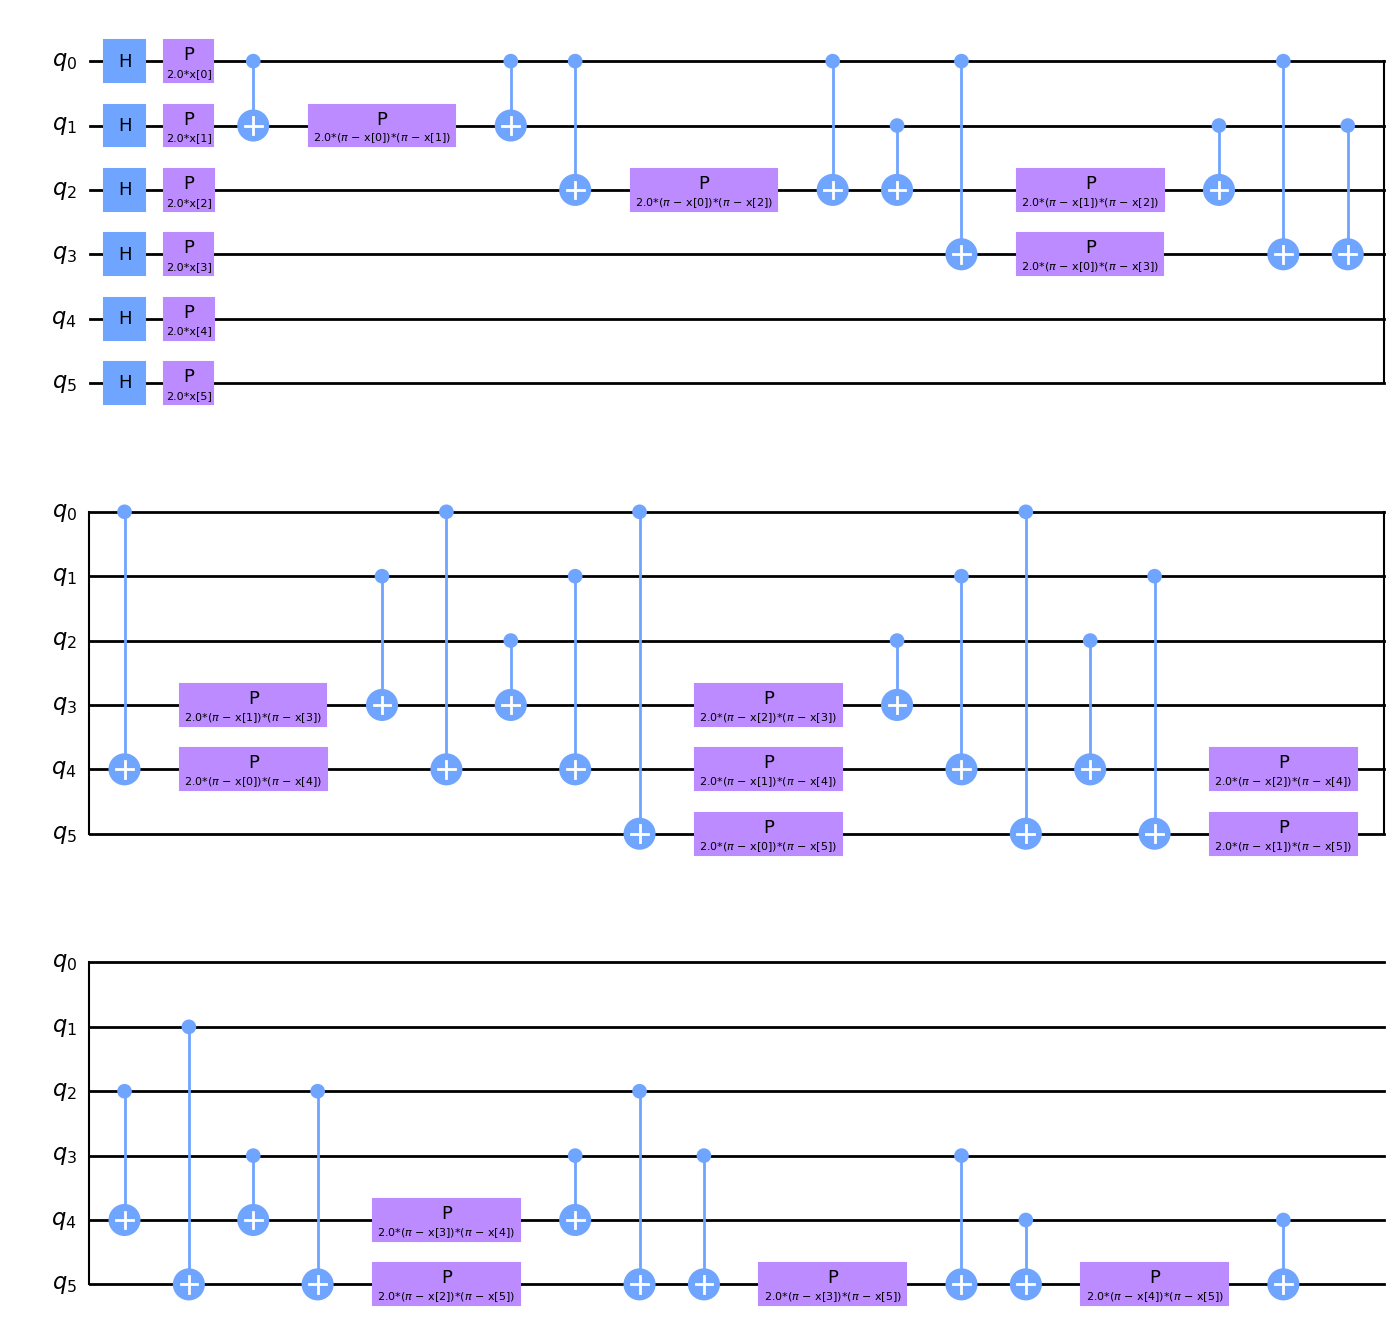

In [48]:
from qiskit.circuit.library import ZZFeatureMap
print(features)
num_features = features.shape[1]

feature_map = ZZFeatureMap(feature_dimension=num_features, reps=1)
print(feature_map)
feature_map.decompose().draw(output="mpl", fold=20)

Number of features need to pass in Quantum Circuit=  6
     »
q_0: »
     »
q_1: »
     »
q_2: »
     »
q_3: »
     »
q_4: »
     »
q_5: »
     »
«     ┌────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
«q_0: ┤0                                                                                                                                                       ├
«     │                                                                                                                                                        │
«q_1: ┤1                                                                                                                                                       ├
«     │                                                                                                                                                        │
«q_2: ┤2                                         

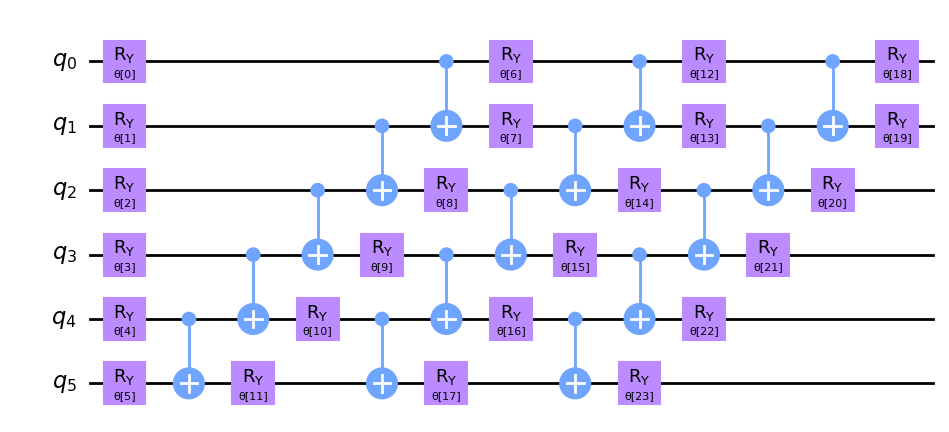

In [49]:
from qiskit.circuit.library import RealAmplitudes

print("Number of features need to pass in Quantum Circuit= ",num_features)
ansatz = RealAmplitudes(num_qubits=num_features, reps=3)
print(ansatz)
ansatz.decompose().draw(output="mpl", fold=20)

In [50]:
from qiskit_algorithms.optimizers import COBYLA

optimizer = COBYLA(maxiter=Num_iter,disp=True, options=None)  # Num_iter=how many time you want to iterate an optimizer
print(optimizer)

In [51]:
from qiskit.primitives import Sampler
sampler = Sampler()
print(sampler)

In [52]:
from matplotlib import pyplot as plt
from IPython.display import clear_output

objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

In [53]:
print("type X_train=",type(X_train))
print("type y_train=",type(y_train))

#convert <class 'pandas.core.frame.DataFrame'> to  <class 'numpy.ndarray'>
df = pd.DataFrame(X_train)
X_train = df.to_numpy()
print("type X_train=",type(X_train))
print("Train features =",X_train,"\n")

#convert <class 'pandas.core.series.Series'> to <class 'pandas.core.frame.DataFrame'>
df_1=y_train.to_frame()
print("type y_train=",type(df_1))
#df_1 = pd.DataFrame(y_train)
#convert <class 'pandas.core.frame.DataFrame'> to  <class 'numpy.ndarray'>
y_train = df_1.to_numpy()
print("type y_train=",type(y_train))
print("Train labels = ",y_train,"\n")

type X_train= <class 'pandas.core.frame.DataFrame'>
type y_train= <class 'pandas.core.series.Series'>
type X_train= <class 'numpy.ndarray'>
Train features = [[0.57006941 0.57825927 0.38381864 0.51777778 0.52764912 0.52556253]
 [0.55692346 0.39996509 0.81383856 0.76444444 0.61843799 0.56459476]
 [0.43200663 0.41504765 0.51647937 0.91111111 0.68206527 0.42097338]
 ...
 [0.4207243  0.15878864 0.48277368 0.06666667 0.90731197 0.44298664]
 [0.50328424 0.47869973 0.35585794 0.46666667 0.46872699 0.34615447]
 [0.63714016 0.7273646  0.69177979 0.51777778 0.80599801 0.85296748]] 

type y_train= <class 'pandas.core.frame.DataFrame'>
type y_train= <class 'numpy.ndarray'>
Train labels =  [[0]
 [0]
 [1]
 ...
 [1]
 [1]
 [0]] 



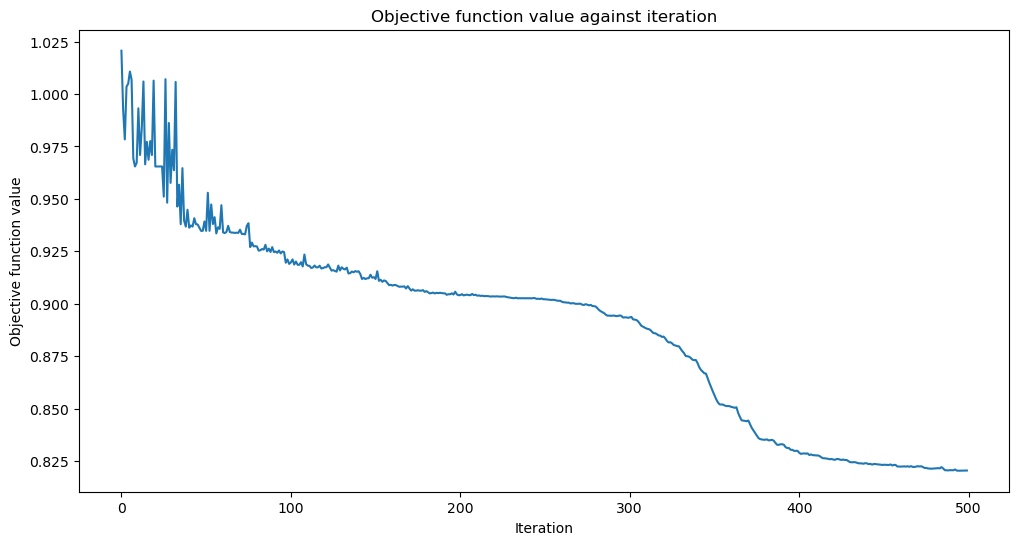

Training time: 188151 seconds


In [54]:
import time
from qiskit_machine_learning.algorithms.classifiers import VQC


vqc = VQC(
    sampler=sampler,
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback_graph,
)

# clear objective value history
objective_func_vals = []

start = time.time()
vqc.fit(X_train,y_train)  # both are in the form of numpy array
elapsed = time.time() - start

print(f"Training time: {round(elapsed)} seconds")

In [55]:
print("Test feature type=",type(X_test))
print("Test labels type=",type(y_test))

#convert <class 'pandas.core.frame.DataFrame'> to  <class 'numpy.ndarray'>
df_2 = pd.DataFrame(X_test)
X_test = df_2.to_numpy()
print("type X_test=",type(X_test))
print("Test features =",X_test,"\n")

#convert <class 'pandas.core.series.Series'> to <class 'pandas.core.frame.DataFrame'>
df_3=y_test.to_frame()
print("type y_test=",type(df_3))
#df_1 = pd.DataFrame(y_train)
#convert <class 'pandas.core.frame.DataFrame'> to  <class 'numpy.ndarray'>
y_test = df_3.to_numpy()
print("type y_test=",type(y_test))
print("Test labels = \n",y_test,"\n")

Test feature type= <class 'pandas.core.frame.DataFrame'>
Test labels type= <class 'pandas.core.series.Series'>
type X_test= <class 'numpy.ndarray'>
Test features = [[0.54477839 0.44697245 0.60597924 0.51555556 0.52724036 0.50374481]
 [0.49371949 0.33185822 0.55712819 0.93777778 0.3720091  0.34939475]
 [0.62117072 0.59966234 0.67800399 0.29777778 0.6188637  0.68526377]
 ...
 [0.60042628 0.47666597 0.55491583 0.44444444 0.53940842 0.56608707]
 [0.77276427 0.34641986 0.52483907 0.75333333 0.1058289  0.36449846]
 [0.58366503 0.46721807 0.47131946 0.10222222 0.40215111 0.47786285]] 

type y_test= <class 'pandas.core.frame.DataFrame'>
type y_test= <class 'numpy.ndarray'>
Test labels = 
 [[0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]


In [56]:
print("Test feature type=",type(X_test))
print("Test labels type=",type(y_test))

train_score_q4_eff = vqc.score(X_train,y_train)
test_score_q4_eff = vqc.score(X_test, y_test)

print(f"Quantum VQC on the training score: {train_score_q4_eff:.2f}")
print(f"Quantum VQC on the test score:     {test_score_q4_eff:.2f}")

Test feature type= <class 'numpy.ndarray'>
Test labels type= <class 'numpy.ndarray'>
Quantum VQC on the training score: 0.80
Quantum VQC on the test score:     0.79
